In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Load the full image data
df = pd.read_csv('/Users/nogashlomi/projects/Image_data/dissertation/full_image_data_feb_25.csv', low_memory=False)

# Load the visual tags for SA 1.7 (Sphericity of Water Element)
visual_tags = pd.read_excel('/Users/nogashlomi/projects/Image_data/visual_tags/VT_1.7_sphericity_water_element.xlsx')

# Merge on cluster_name
df_full = pd.merge(df, visual_tags, on='cluster_name', how='left')

# Drop rows where year or place or custom_identifier might be null
# And also clean the custom_identifier to string for plotting colors
df_clean = df_full.dropna(subset=['year', 'place', 'custom_identifier']).copy()
df_clean['custom_identifier_str'] = df_clean['custom_identifier'].astype(int).astype(str)

print("Data loaded perfectly.")


Data loaded perfectly.



Total specific images for Water Sphericity with 'full circle' == 'yes': 168


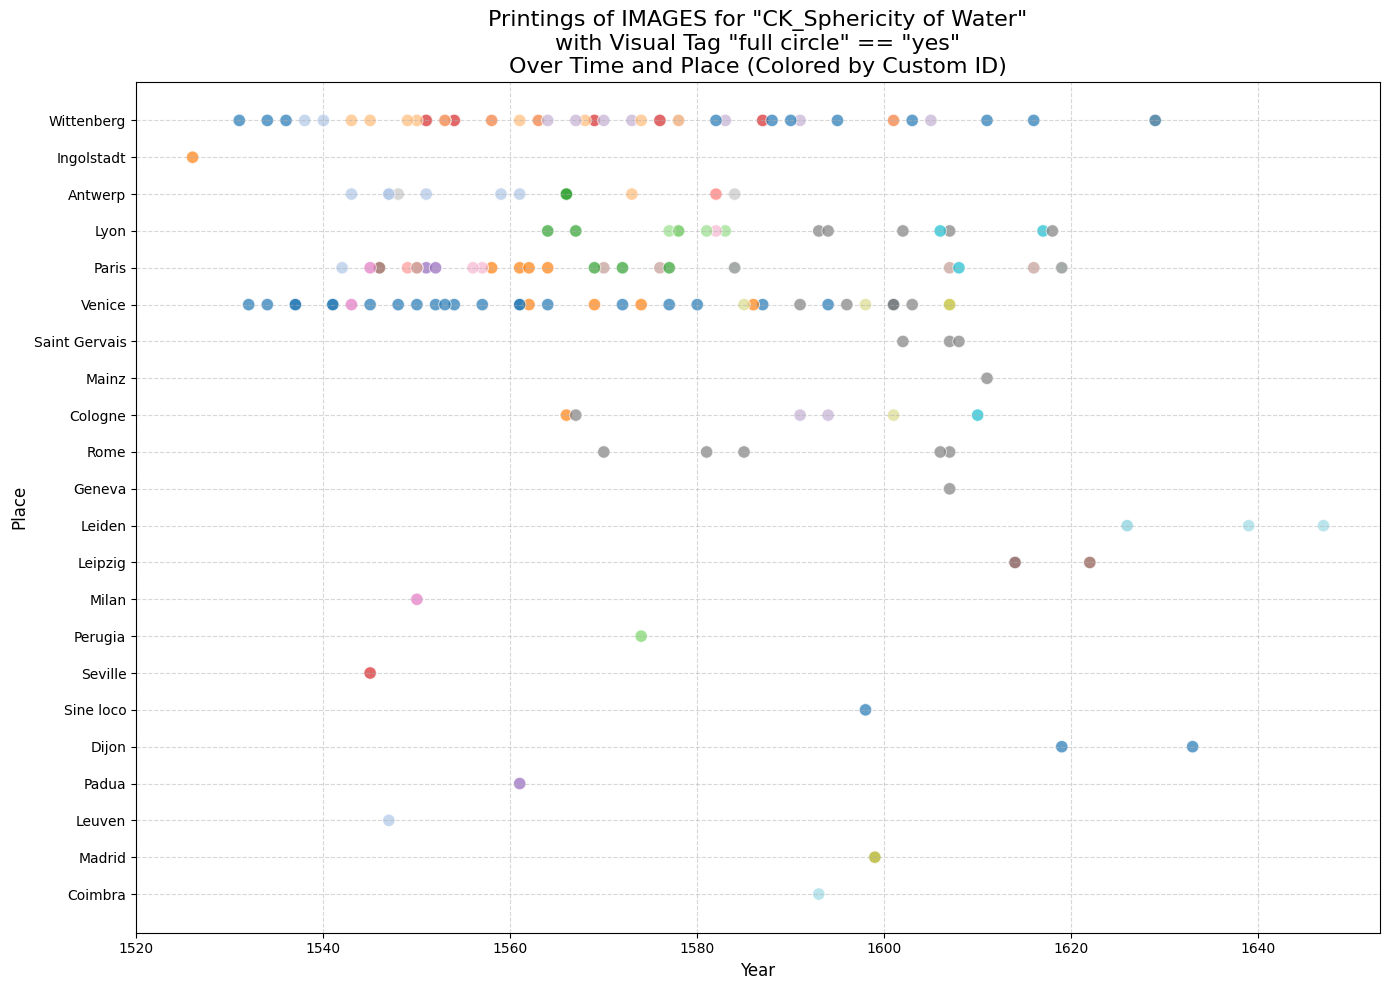

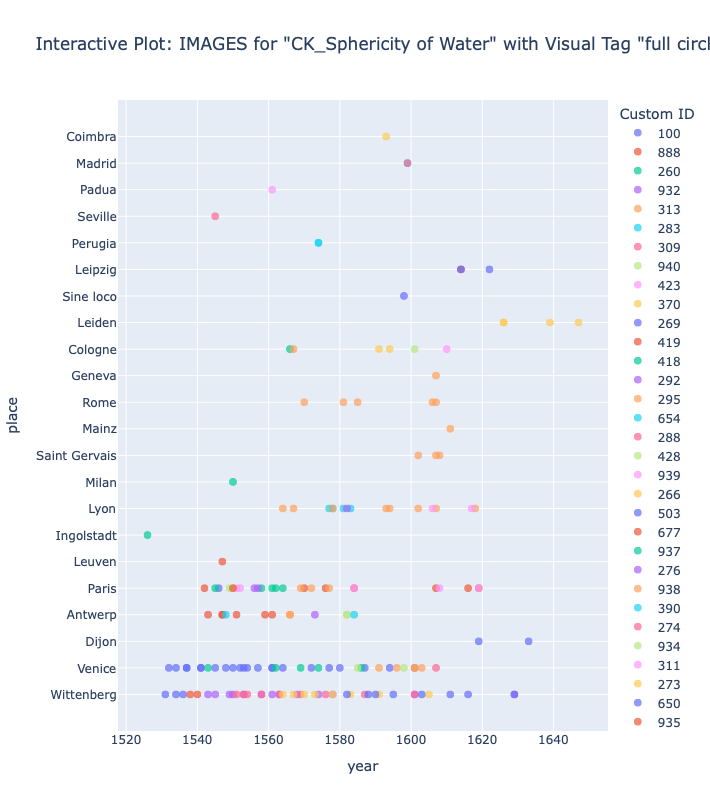

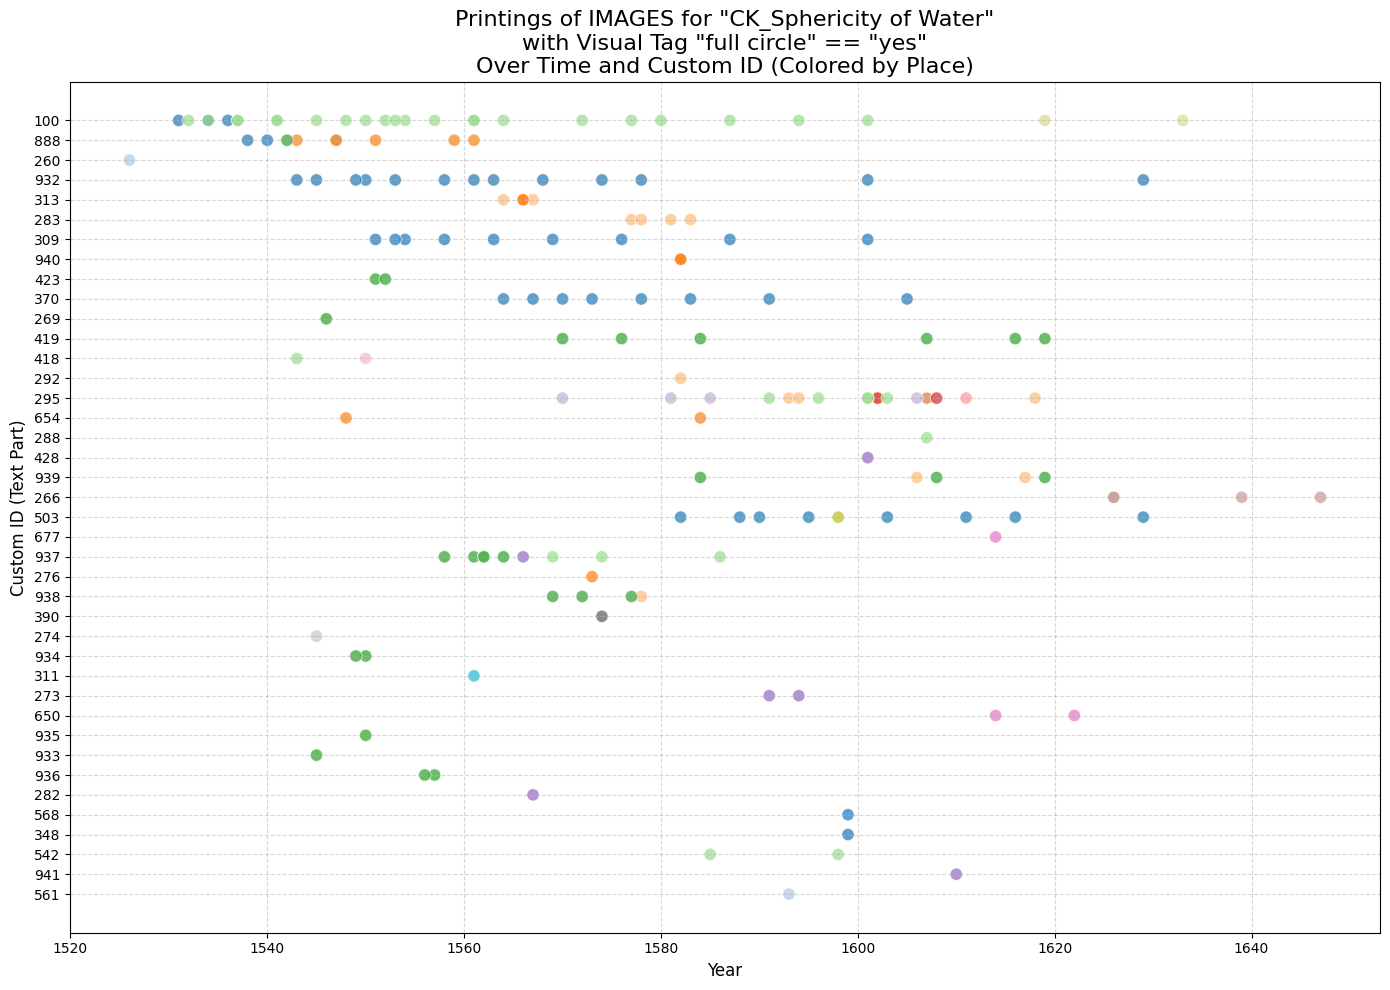

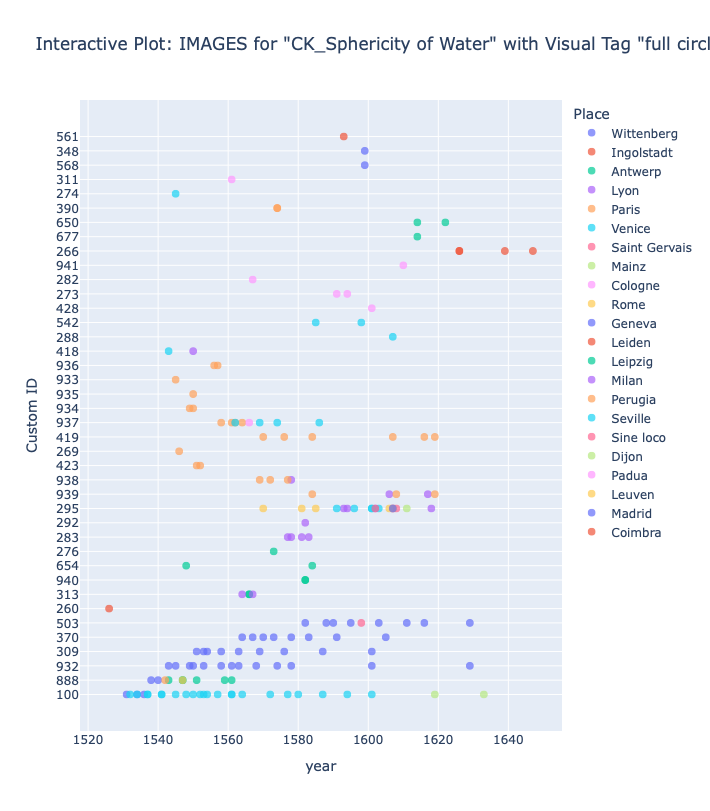

In [5]:
# Scatter Plots for 'full circle' == 'yes'
tag_col = 'full circle'
base_ck = 'CK_Sphericity of Water'

# Filter for the specific CK (or variations of it like Sphericity of the Water/Element)
# We will use string contains to be safe, as it might be named slightly differently
df_fc = df_clean[(df_clean['cks'].str.contains('Water', na=False, case=False)) & (df_clean[tag_col] == 'yes')].copy()

# Drop duplicates on images to count each unique image only once
df_fc = df_fc.drop_duplicates(subset=['images']).copy()

print(f"\nTotal specific images for Water Sphericity with '{tag_col}' == 'yes': {len(df_fc)}")

if len(df_fc) > 0:
    # 1. Static Scatter Plot (Place vs Time)
    plt.figure(figsize=(14, 10))
    sns.scatterplot(
        data=df_fc, x='year', y='place', hue='custom_identifier_str',
        palette='tab20', s=80, alpha=0.7, legend=False 
    )
    plt.title(f'Printings of IMAGES for "{base_ck}"\nwith Visual Tag "{tag_col}" == "yes"\nOver Time and Place (Colored by Custom ID)', fontsize=16)
    plt.xlabel('Year', fontsize=12)
    plt.ylabel('Place', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

    # 2. Interactive Scatter Plot (Place vs Time)
    fig_fc_place = px.scatter(
        df_fc, x='year', y='place', color='custom_identifier_str',
        hover_data=['part_or_adaption_label', 'images', 'bid', 'book'],
        title=f'Interactive Plot: IMAGES for "{base_ck}" with Visual Tag "{tag_col}" == "yes" (by Place)',
        labels={'custom_identifier_str': 'Custom ID'}
    )
    fig_fc_place.update_traces(marker=dict(size=8, opacity=0.7))
    fig_fc_place.update_layout(height=800, hovermode='closest')
    fig_fc_place.show()

    # 3. Static Scatter Plot (Custom ID vs Time)
    plt.figure(figsize=(14, 10))
    sns.scatterplot(
        data=df_fc, x='year', y='custom_identifier_str', hue='place',
        palette='tab20', s=80, alpha=0.7, legend=False 
    )
    plt.title(f'Printings of IMAGES for "{base_ck}"\nwith Visual Tag "{tag_col}" == "yes"\nOver Time and Custom ID (Colored by Place)', fontsize=16)
    plt.xlabel('Year', fontsize=12)
    plt.ylabel('Custom ID (Text Part)', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

    # 4. Interactive Scatter Plot (Custom ID vs Time)
    fig_fc = px.scatter(
        df_fc, x='year', y='custom_identifier_str', color='place',
        hover_data=['part_or_adaption_label', 'images', 'bid', 'book'],
        title=f'Interactive Plot: IMAGES for "{base_ck}" with Visual Tag "{tag_col}" == "yes" (by Custom ID)',
        labels={'custom_identifier_str': 'Custom ID', 'place': 'Place'}
    )
    fig_fc.update_traces(marker=dict(size=8, opacity=0.7))
    fig_fc.update_layout(height=800, hovermode='closest')
    fig_fc.show()
else:
    print(f"No images found for '{tag_col}' == 'yes'.")



Total specific images for Water Sphericity with 'not full circle' == 'yes': 75


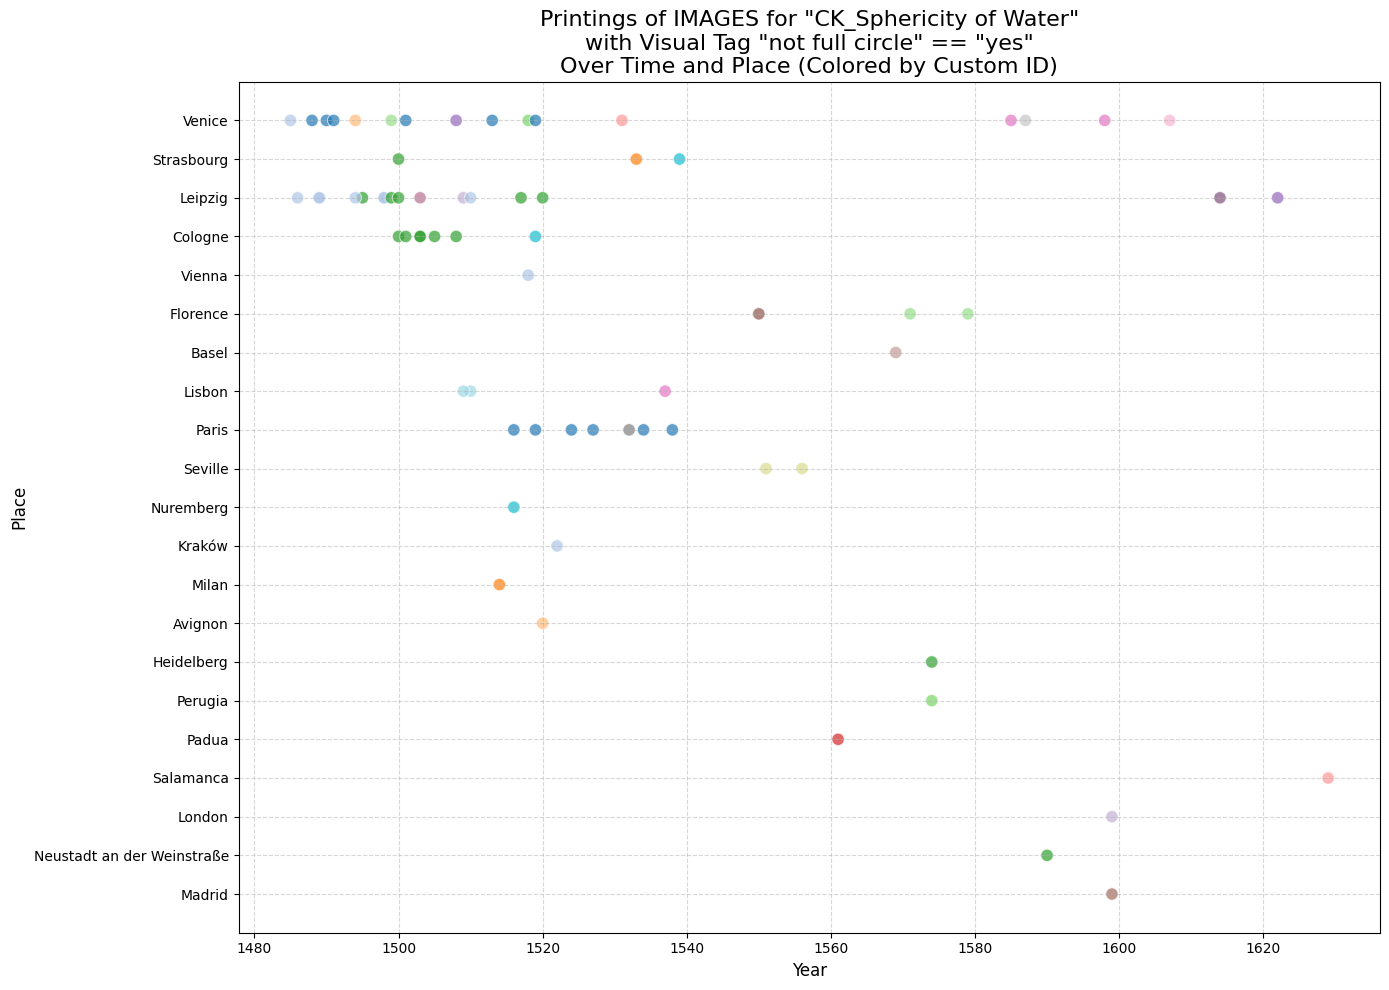

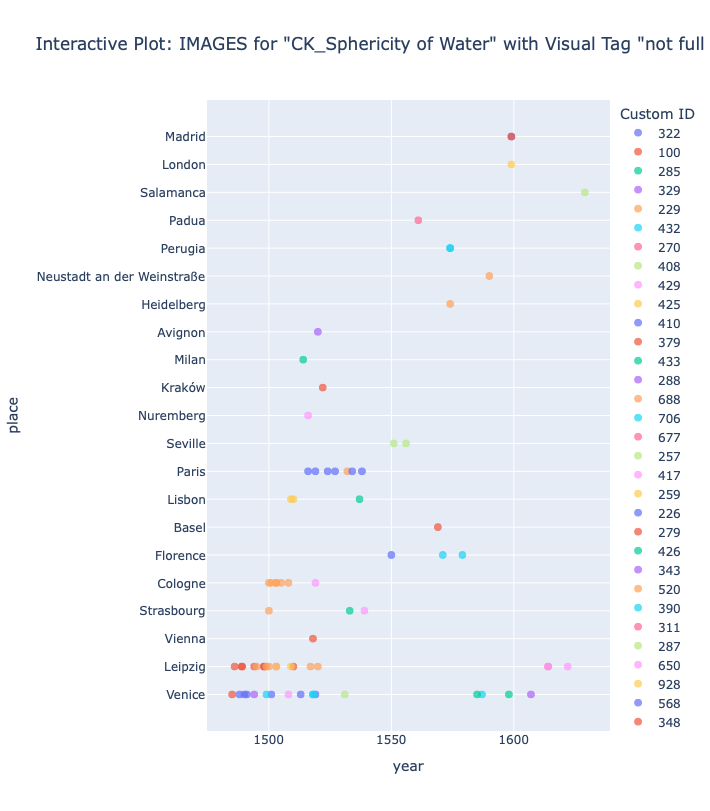

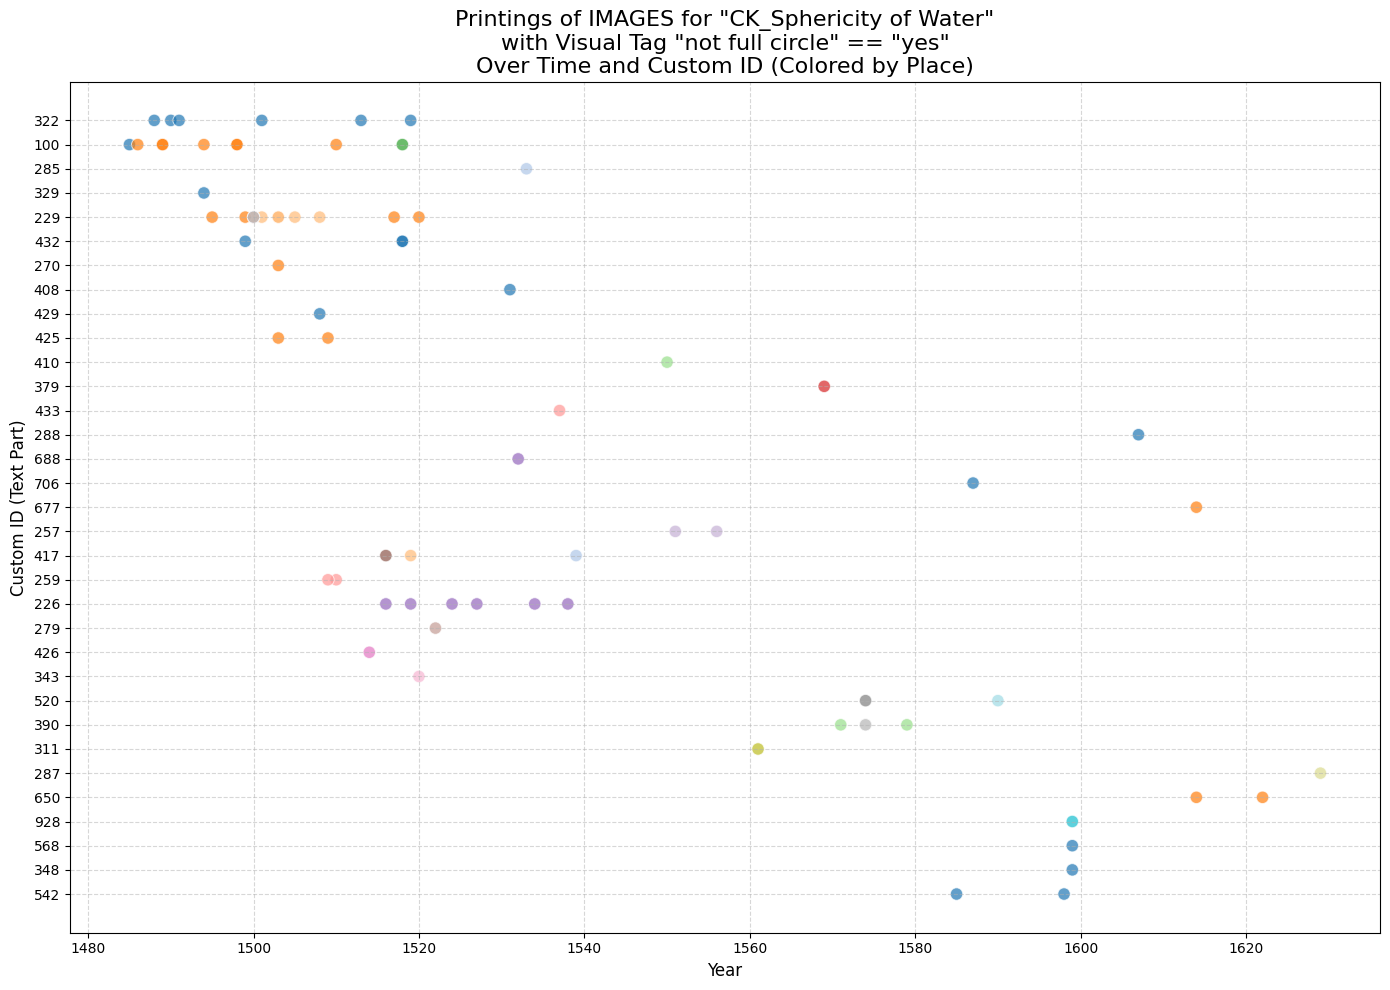

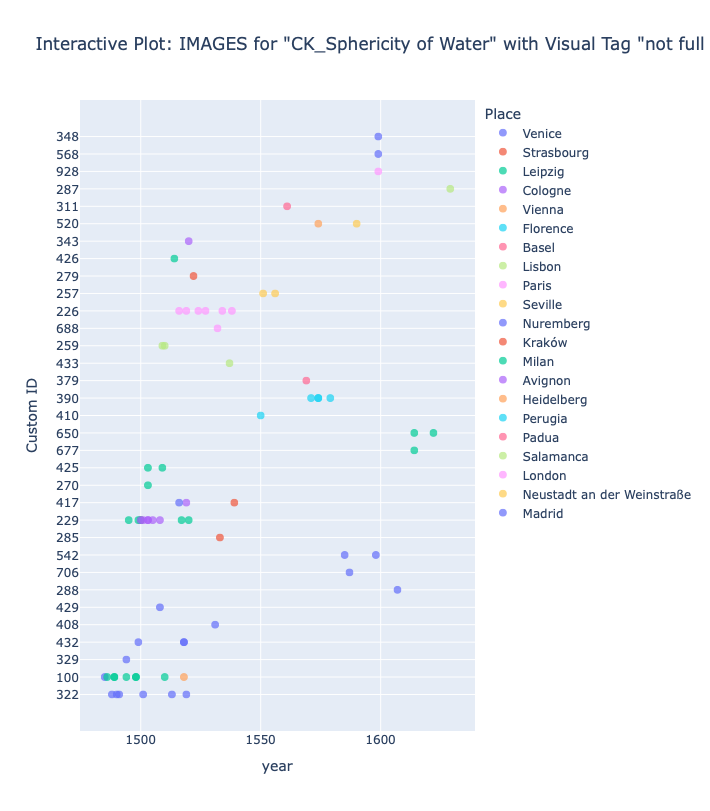

In [6]:
# Scatter Plots for 'not full circle' == 'yes'
tag_col_not = 'not full circle'

df_nfc = df_clean[(df_clean['cks'].str.contains('Water', na=False, case=False)) & (df_clean[tag_col_not] == 'yes')].copy()
df_nfc = df_nfc.drop_duplicates(subset=['images']).copy()

print(f"\nTotal specific images for Water Sphericity with '{tag_col_not}' == 'yes': {len(df_nfc)}")

if len(df_nfc) > 0:
    # 1. Static Scatter Plot (Place vs Time)
    plt.figure(figsize=(14, 10))
    sns.scatterplot(
        data=df_nfc, x='year', y='place', hue='custom_identifier_str',
        palette='tab20', s=80, alpha=0.7, legend=False 
    )
    plt.title(f'Printings of IMAGES for "{base_ck}"\nwith Visual Tag "{tag_col_not}" == "yes"\nOver Time and Place (Colored by Custom ID)', fontsize=16)
    plt.xlabel('Year', fontsize=12)
    plt.ylabel('Place', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

    # 2. Interactive Scatter Plot (Place vs Time)
    fig_nfc_place = px.scatter(
        df_nfc, x='year', y='place', color='custom_identifier_str',
        hover_data=['part_or_adaption_label', 'images', 'bid', 'book'],
        title=f'Interactive Plot: IMAGES for "{base_ck}" with Visual Tag "{tag_col_not}" == "yes" (by Place)',
        labels={'custom_identifier_str': 'Custom ID'}
    )
    fig_nfc_place.update_traces(marker=dict(size=8, opacity=0.7))
    fig_nfc_place.update_layout(height=800, hovermode='closest')
    fig_nfc_place.show()

    # 3. Static Scatter Plot (Custom ID vs Time)
    plt.figure(figsize=(14, 10))
    sns.scatterplot(
        data=df_nfc, x='year', y='custom_identifier_str', hue='place',
        palette='tab20', s=80, alpha=0.7, legend=False 
    )
    plt.title(f'Printings of IMAGES for "{base_ck}"\nwith Visual Tag "{tag_col_not}" == "yes"\nOver Time and Custom ID (Colored by Place)', fontsize=16)
    plt.xlabel('Year', fontsize=12)
    plt.ylabel('Custom ID (Text Part)', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

    # 4. Interactive Scatter Plot (Custom ID vs Time)
    fig_nfc = px.scatter(
        df_nfc, x='year', y='custom_identifier_str', color='place',
        hover_data=['part_or_adaption_label', 'images', 'bid', 'book'],
        title=f'Interactive Plot: IMAGES for "{base_ck}" with Visual Tag "{tag_col_not}" == "yes" (by Custom ID)',
        labels={'custom_identifier_str': 'Custom ID', 'place': 'Place'}
    )
    fig_nfc.update_traces(marker=dict(size=8, opacity=0.7))
    fig_nfc.update_layout(height=800, hovermode='closest')
    fig_nfc.show()
else:
    print(f"No images found for '{tag_col_not}' == 'yes'.")



Total specific images for Water Sphericity with 'diagram' == 'yes': 75


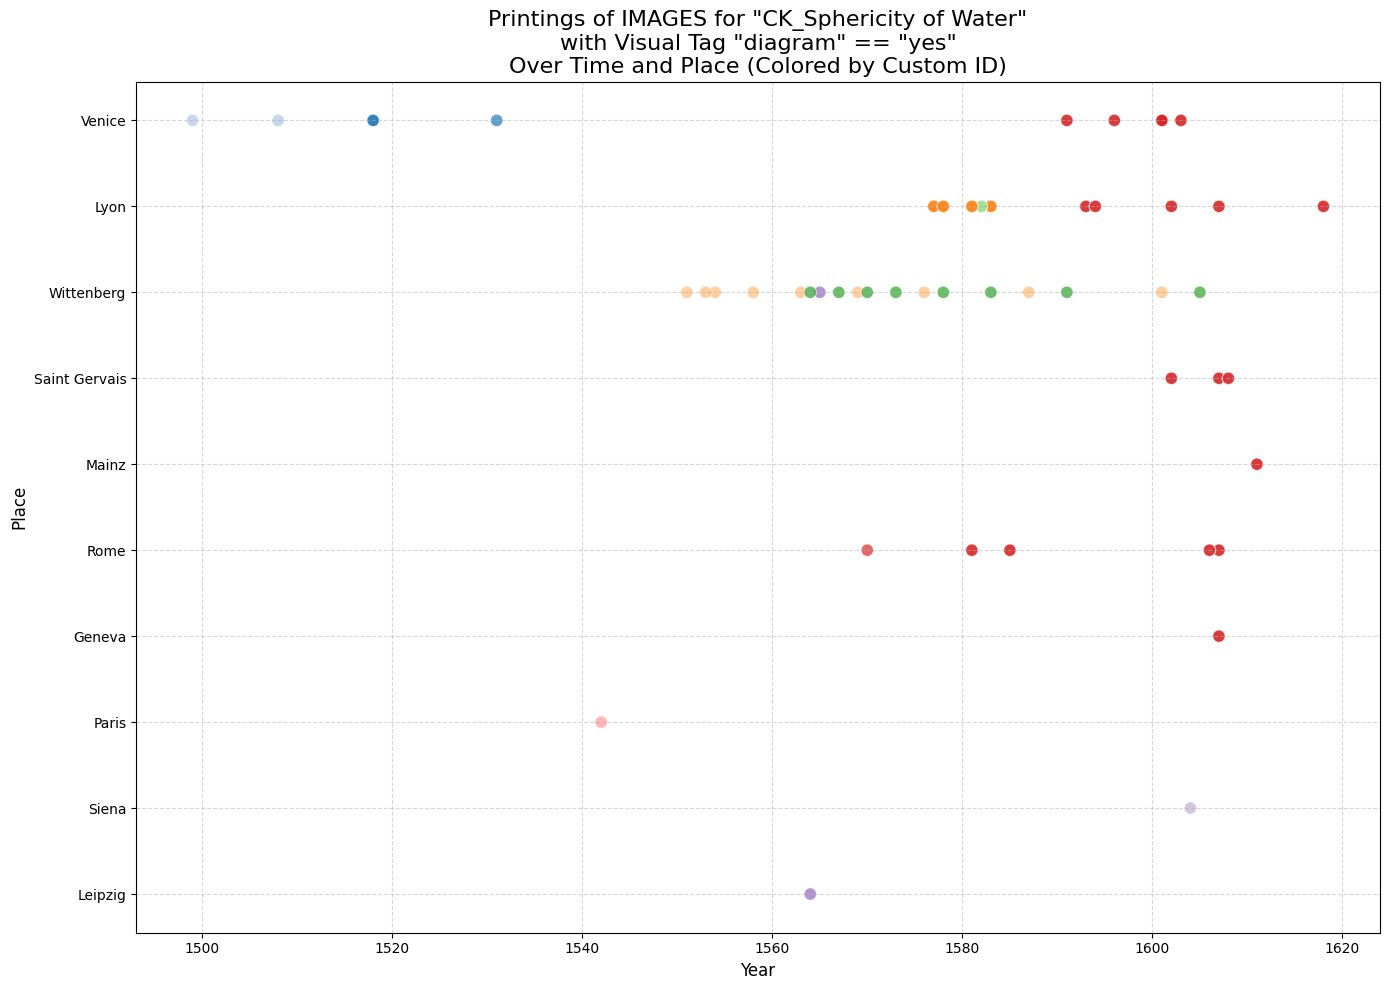

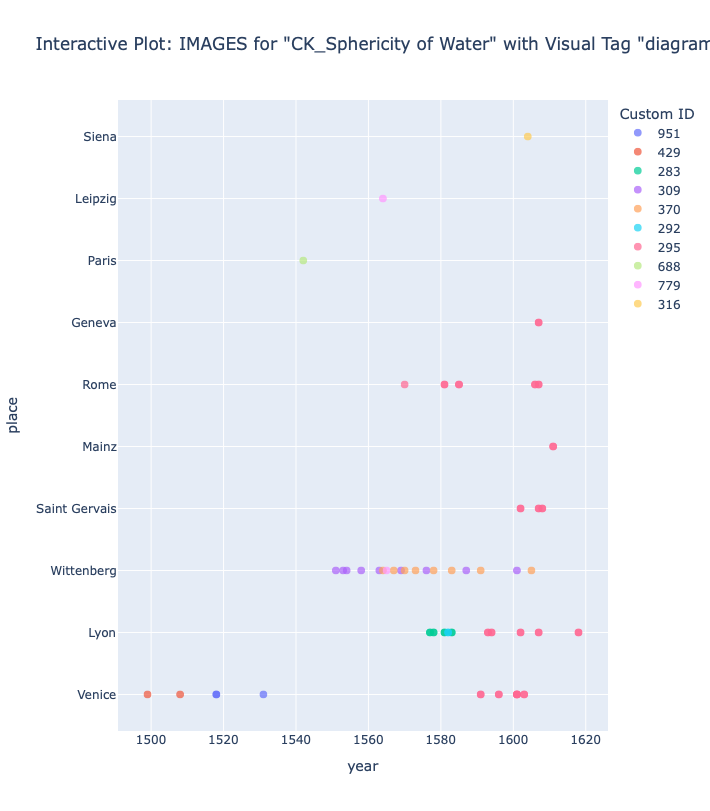

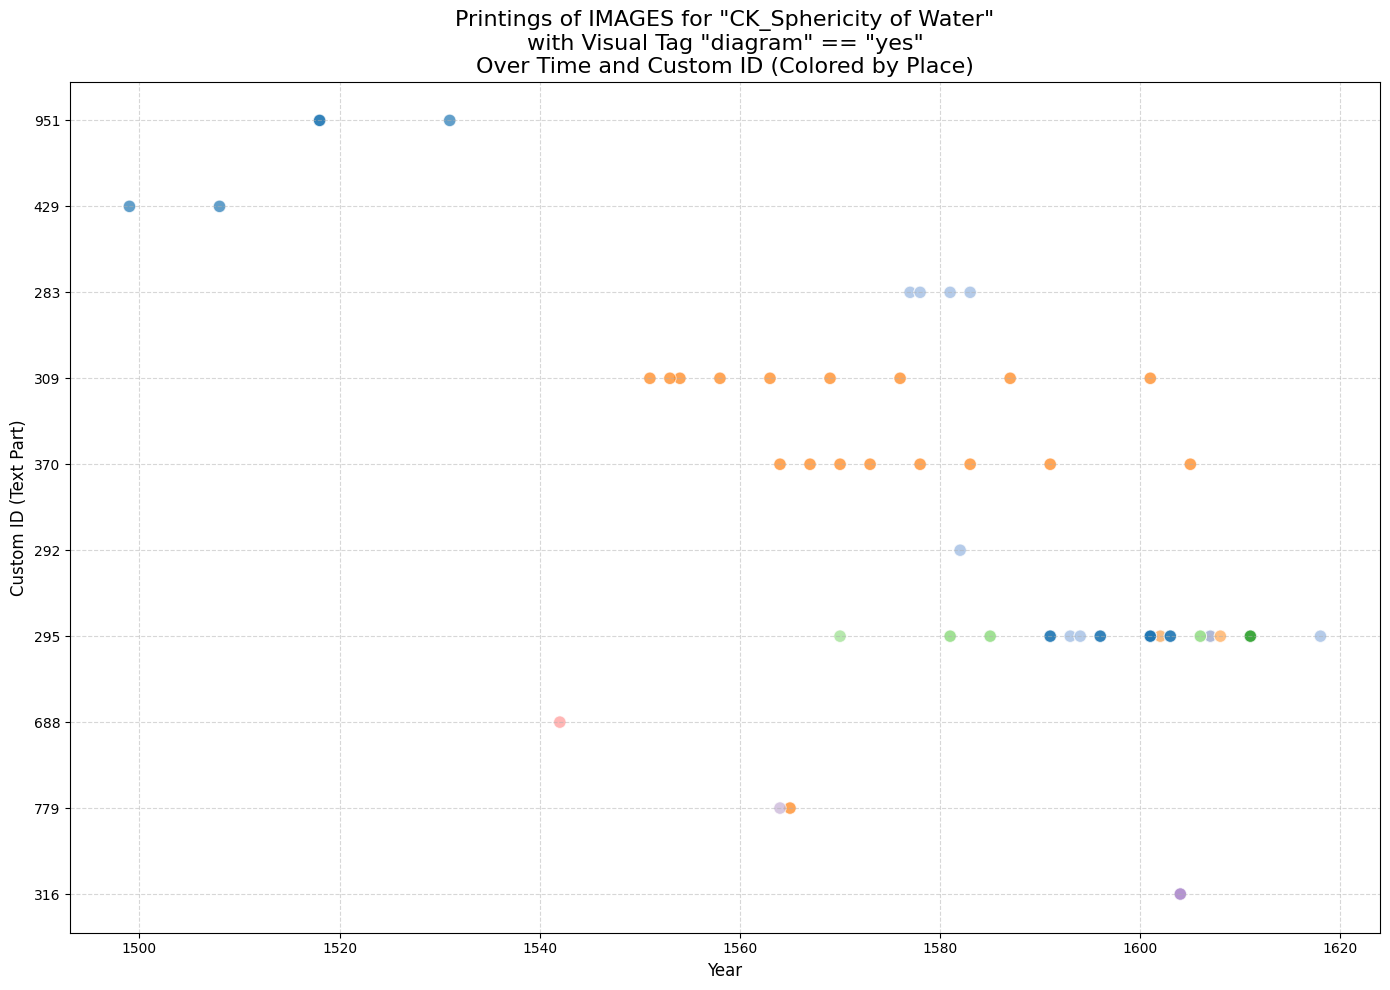

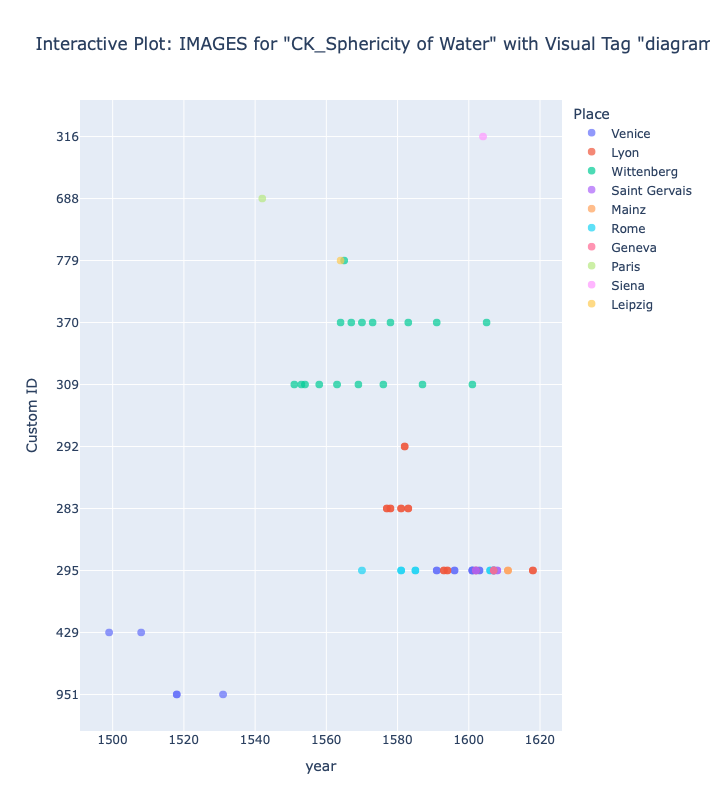

In [7]:
# Scatter Plots for 'diagram' == 'yes'
tag_col_diag = 'diagram'

df_diag = df_clean[(df_clean['cks'].str.contains('Water', na=False, case=False)) & (df_clean[tag_col_diag] == 'yes')].copy()
df_diag = df_diag.drop_duplicates(subset=['images']).copy()

print(f"\nTotal specific images for Water Sphericity with '{tag_col_diag}' == 'yes': {len(df_diag)}")

if len(df_diag) > 0:
    # 1. Static Scatter Plot (Place vs Time)
    plt.figure(figsize=(14, 10))
    sns.scatterplot(
        data=df_diag, x='year', y='place', hue='custom_identifier_str',
        palette='tab20', s=80, alpha=0.7, legend=False 
    )
    plt.title(f'Printings of IMAGES for "{base_ck}"\nwith Visual Tag "{tag_col_diag}" == "yes"\nOver Time and Place (Colored by Custom ID)', fontsize=16)
    plt.xlabel('Year', fontsize=12)
    plt.ylabel('Place', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

    # 2. Interactive Scatter Plot (Place vs Time)
    fig_diag_place = px.scatter(
        df_diag, x='year', y='place', color='custom_identifier_str',
        hover_data=['part_or_adaption_label', 'images', 'bid', 'book'],
        title=f'Interactive Plot: IMAGES for "{base_ck}" with Visual Tag "{tag_col_diag}" == "yes" (by Place)',
        labels={'custom_identifier_str': 'Custom ID'}
    )
    fig_diag_place.update_traces(marker=dict(size=8, opacity=0.7))
    fig_diag_place.update_layout(height=800, hovermode='closest')
    fig_diag_place.show()

    # 3. Static Scatter Plot (Custom ID vs Time)
    plt.figure(figsize=(14, 10))
    sns.scatterplot(
        data=df_diag, x='year', y='custom_identifier_str', hue='place',
        palette='tab20', s=80, alpha=0.7, legend=False 
    )
    plt.title(f'Printings of IMAGES for "{base_ck}"\nwith Visual Tag "{tag_col_diag}" == "yes"\nOver Time and Custom ID (Colored by Place)', fontsize=16)
    plt.xlabel('Year', fontsize=12)
    plt.ylabel('Custom ID (Text Part)', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

    # 4. Interactive Scatter Plot (Custom ID vs Time)
    fig_diag = px.scatter(
        df_diag, x='year', y='custom_identifier_str', color='place',
        hover_data=['part_or_adaption_label', 'images', 'bid', 'book'],
        title=f'Interactive Plot: IMAGES for "{base_ck}" with Visual Tag "{tag_col_diag}" == "yes" (by Custom ID)',
        labels={'custom_identifier_str': 'Custom ID', 'place': 'Place'}
    )
    fig_diag.update_traces(marker=dict(size=8, opacity=0.7))
    fig_diag.update_layout(height=800, hovermode='closest')
    fig_diag.show()
else:
    print(f"No images found for '{tag_col_diag}' == 'yes'.")
